This is to test whether the ordering algorithm chat gpt gave me is correct

In [3]:
import math
from typing import List
import matplotlib.pyplot as plt


In [2]:
def generate_presentation_location_order(x_pos: List[float],
                                         y_pos: List[float],
                                         ) -> List[int]:
    """ WRITTEN BY AI
    Generates an ordering of the presentation locations such that the *total*
    (and therefore average) distance between consecutive locations is (approximately)
    maximized.

    Heuristic:
      1) Start from the farthest pair of points.
      2) Greedy max-insertion: insert each remaining point at the position that maximizes
         the *increase* in open-path length (including inserting at either end).
      3) Apply a 2-opt improvement pass for an open path to further increase length.

    Returns:
        ordering_idxs: a permutation of range(len(x_pos)).
    """
    assert len(x_pos) == len(y_pos), "x_pos and y_pos must have the same length"
    n = len(x_pos)
    if n <= 2:
        return list(range(n))

    # --- helpers ---
    def dist(i: int, j: int) -> float:
        dx = x_pos[i] - x_pos[j]
        dy = y_pos[i] - y_pos[j]
        return math.hypot(dx, dy)

    # total length of an open path
    def path_len(path: List[int]) -> float:
        return sum(dist(path[k], path[k+1]) for k in range(len(path)-1))

    # delta if we insert idx at position pos in path (between pos-1 and pos)
    # pos can be 0..len(path) inclusive; pos==0 or pos==len(path) means "at an end"
    def insertion_delta(path: List[int], idx: int, pos: int) -> float:
        if pos == 0:
            # insert at front: adds edge idx->path[0]
            return dist(idx, path[0])
        elif pos == len(path):
            # insert at end: adds edge path[-1]->idx
            return dist(path[-1], idx)
        else:
            a, b = path[pos-1], path[pos]
            # old edge a->b is replaced by a->idx and idx->b
            return dist(a, idx) + dist(idx, b) - dist(a, b)

    # open-path 2-opt: try reversing segments to increase total length
    def two_opt_open(path: List[int]) -> List[int]:
        improved = True
        while improved:
            improved = False
            L = len(path)
            # edges are (i-1,i) and (k, k+1) with 1 <= i < k < L-1
            for i in range(1, L-1):
                a, b = path[i-1], path[i]
                for k in range(i+1, L-0-1):  # k <= L-2
                    c, d = path[k], path[k+1]
                    gain = (dist(a, c) + dist(b, d)) - (dist(a, b) + dist(c, d))
                    if gain > 1e-12:
                        # Reverse the segment [i, k]
                        path[i:k+1] = reversed(path[i:k+1])
                        improved = True
                        break
                if improved:
                    break
        return path

    # --- 1) seed with farthest pair ---
    max_d = -1.0
    seed_i, seed_j = 0, 1
    for i in range(n):
        for j in range(i+1, n):
            d = dist(i, j)
            if d > max_d:
                max_d = d
                seed_i, seed_j = i, j
    path = [seed_i, seed_j]

    remaining = set(range(n))
    remaining.discard(seed_i)
    remaining.discard(seed_j)

    # --- 2) greedy max-insertion ---
    while remaining:
        best_idx = None
        best_pos = None
        best_delta = -float('inf')
        for idx in remaining:
            # try all insertion positions, including ends
            for pos in range(len(path) + 1):
                delta = insertion_delta(path, idx, pos)
                if delta > best_delta:
                    best_delta = delta
                    best_idx = idx
                    best_pos = pos
        # perform the best insertion
        path.insert(best_pos, best_idx)
        remaining.remove(best_idx)

    # --- 3) 2-opt improvement for open path ---
    path = two_opt_open(path)

    # return permutation of indices
    ordering_idxs = path
    return ordering_idxs

In [10]:
def plot_ordering(x_pos: List[float], y_pos: List[float], ordering: List[int]) -> None:
    """Plot the presentation locations in the order specified by `ordering`. 
    It plots lines between the locations . Also adds a small text label to each point denoting the new ordering."""
    plt.figure(figsize=(8, 8))
    for i in range(len(ordering) - 1):
        start = ordering[i]
        end = ordering[i + 1]
        plt.plot([x_pos[start], x_pos[end]], [y_pos[start], y_pos[end]], 'bo-')
    
    
    # add text labels for each point
    for i, idx in enumerate(ordering):
        plt.text(x_pos[idx], y_pos[idx], str(i), fontsize=12, ha='right', va='bottom')

    plt.scatter(x_pos, y_pos, color='red', label='Locations')
    plt.title('Presentation Location Order')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()


Ordering: [0, 2, 1]


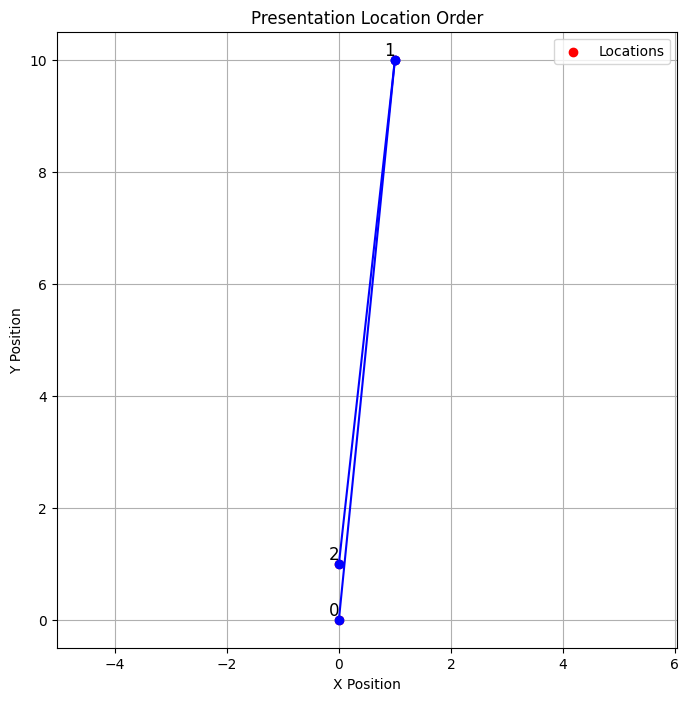

In [13]:
x_pos = [0,0,1]
y_pos = [0, 1, 10]
ordering = generate_presentation_location_order(x_pos, y_pos)
print("Ordering:", ordering)
plot_ordering(x_pos, y_pos, ordering)

looks good, lets test cases with two times the same position

Ordering: [1, 3, 0, 2]


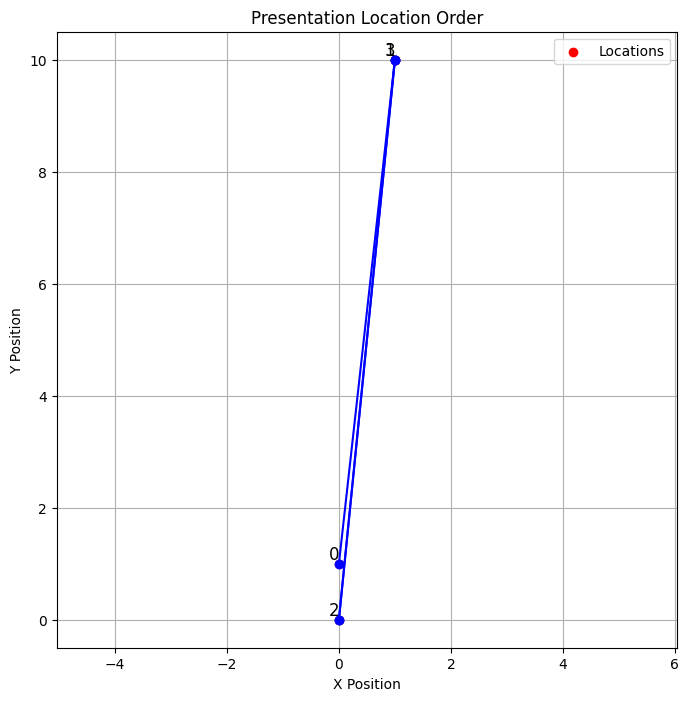

In [15]:
x_pos = [0,0,1,1]
y_pos = [0, 1, 10,10]
ordering = generate_presentation_location_order(x_pos, y_pos)
print("Ordering:", ordering)
plot_ordering(x_pos, y_pos, ordering)

seems to correclty skip the duplicate points and order the remaining ones.

Ordering: [3, 1, 0, 2]


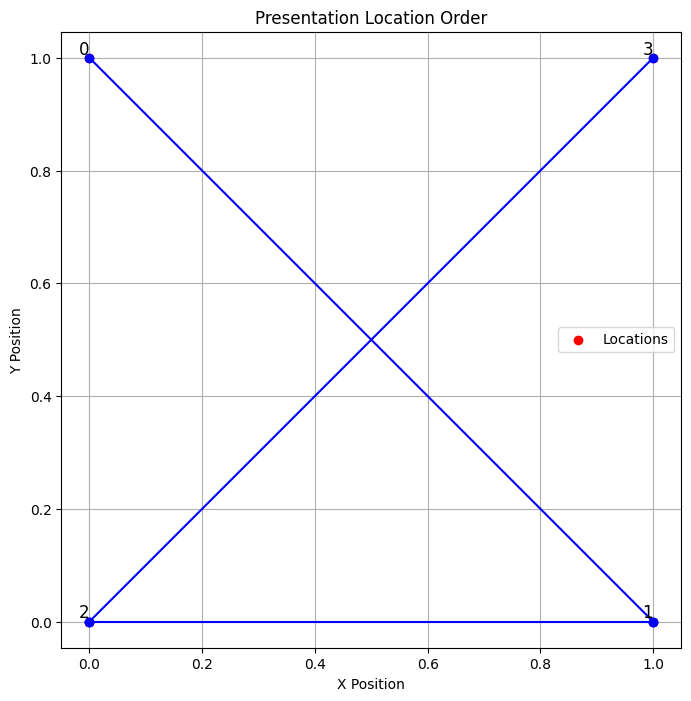

In [ ]:
x_pos = [0,1,1,0]
y_pos = [0, 0,1 ,1]
ordering = generate_presentation_location_order(x_pos, y_pos)
print("Ordering:", ordering)
plot_ordering(x_pos, y_pos, ordering)

Ordering: [2, 0, 1, 3]


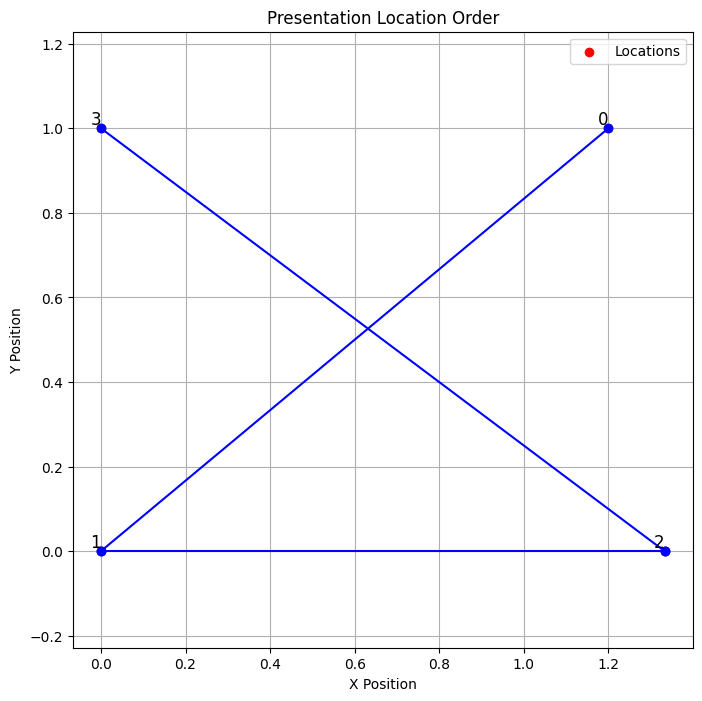

In [17]:
x_pos = [0,1.333,1.2,0]
y_pos = [0, 0,1 ,1]
ordering = generate_presentation_location_order(x_pos, y_pos)
print("Ordering:", ordering)
plot_ordering(x_pos, y_pos, ordering)